# 환경 준비

## G-drive에서 model caching 하기

In [1]:
## caching folder변경 -- 오히려 늦어 지면 remark 하세요.

# from google.colab import drive
# drive.mount('/content/drive')

# import os
# gdrive_path ="/content/drive/MyDrive/Colab Notebooks/models/LLM"
# os.environ["HF_HOME"] = gdrive_path + "/hf_cache"
# os.environ["HF_DATASETS_CACHE"] = gdrive_path + "/hf_cache/datasets"
# os.environ["TRANSFORMERS_CACHE"] = gdrive_path + "/hf_cache/transformers"

## HuggingFace Token 설정

In [2]:
# Colab secrets에서 토큰 불러오기
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN') # 'HF_TOKEN'은 Colab secrets에 저장한 토큰 이름
!hf auth whoami

user:  gshong
orgs:  LLM2506,aicmap


## Quantization library 설치

In [3]:
%%time
## bitsandbytes : Quantization을 위해 필요
!pip install bitsandbytes -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 9.5 MB/s eta 0:00:00
CPU times: user 1.43 s, sys: 211 ms, total: 1.65 s
Wall time: 10.7 s


In [4]:
import torch
import transformers, accelerate # 설치되어 있음
import bitsandbytes

torch.__version__, transformers.__version__,accelerate.__version__,bitsandbytes.__version__
#( 2.6.0+cu124,   4.51.3 ) 2505
#('2.8.0+cu126', '4.56.1', '1.10.1', '0.47.0')   2509
#('2.8.0+cu126', '4.57.1', '1.10.1', '0.48.1')   2510
#('2.8.0+cu126', '4.57.1', '1.11.0', '0.48.2')   2511
#('2.9.0+cu126', '4.57.6', '1.12.0', '0.49.1')   2601

('2.9.0+cu126', '4.57.6', '1.12.0', '0.49.1')

## Chatting UI : Gradio 설치
접속 가능한 임시 공유 링크를 생성함  
이 링크는 보통 7일 후에 만료됨   
Colab에서는 런타임이 종료되면 바로 접속이 불가능

In [5]:
!pip install gradio -q
import gradio as gr

# Pineline 사용 ChatBot 사용해 보기

## Llama-3-8B 8bit Quantized model
### [PrunaAI/NCSOFT-Llama-3-OffsetBias-8B-bnb-8bit-smashed](https://huggingface.co/PrunaAI/NCSOFT-Llama-3-OffsetBias-8B-bnb-8bit-smashed)   


### Llama-3 계열 모델을 위한 대화 [템플릿](https://huggingface.co/docs/transformers/main/model_doc/llama3#transformers.Llama3Tokenizer)    
  <|begin_of_text|><|start_header_id|>system<|end_header_id|>  
  당신은 정중하고 유익한 한국어 인공지능입니다.<|eot_id|>  
  <|start_header_id|>user<|end_header_id|>  
  {input_text}<|eot_id|>  
  <|start_header_id|>assistant<|end_header_id|>

**커스텀 템플릿**이 적용된 경우도 있으므로 tokenizer에서 제공되는 template를 사용하는것이 좋음        

    tokenizer.apply_chat_template( )

In [6]:
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [7]:
%%time
model_name = "PrunaAI/NCSOFT-Llama-3-OffsetBias-8B-bnb-8bit-smashed"  # 8.5GB

# 8비트 양자화를 위한 BitsAndBytesConfig 설정 필요없음
# quantization_config = BitsAndBytesConfig( load_in_8bit=True,)

# 모델과 토크나이저 로드 (custom code 사용 가능성 있음)
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    # quantization_config=quantization_config,
    device_map="auto", # GPU 자동 설정
    trust_remote_code=True, )

# 텍스트 생성 파이프라인 설정
chatbot = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map="auto") # 파이프라인도 동일하게 device_map 사용

# Llama-3 계열 모델을 위한 대화 템플릿 구성
def chat_with_llama3_quantized(input_text):
    messages = [
        {"role": "system", "content": "당신은 정중하고 유익한 한국어 인공지능입니다."},
        {"role": "user", "content": input_text}, ]

    # apply_chat_template을 사용하여 프롬프트 문자열 생성
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False, # 토크나이저가 직접 텍스트를 반환
        add_generation_prompt=True )#<|start_header_id|>assistant<|end_header_id|> 추가

    response = chatbot(
        prompt,
        max_new_tokens=256,
        temperature=0.7,
        do_sample=True,
        eos_token_id=tokenizer.eos_token_id, # Llama-3의 EOS 토큰 ID 사용
        pad_token_id=tokenizer.eos_token_id,
        return_full_text=False,
    )[0]["generated_text"] ## 생성되는 text중 첫번째 선택

    return response

# Wall time: 54.6 s

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/4.09G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

Device set to use cuda:0


CPU times: user 21 s, sys: 29 s, total: 50 s
Wall time: 44 s


**prompt**  
    <|begin_of_text|><|start_header_id|>system<|end_header_id|>
    <|eot_id|><|start_header_id|>assistant<|end_header_id|>
    <|start_header_id|>system<|end_header_id|>
    당신은 정중하고 유익한 한국어 인공지능입니다.<|eot_id|><|start_header_id|>user<|end_header_id|>
    너의 지적 수준을 객관적으로 설명해봐. 한국어로 설명해줘.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

**response**    
[{'generated_text': '저는 AI의 지적 수준을 객관적으로 설명합니다.    
...  
이러한 지적 수준이 객관적으로 설명되었습니다.assistant  
I apologize for the confusion,'}]


    print(tokenizer.chat_template)  # 커스텀 템플릿 구조 확인해 보면 다음과 같이 보임   

{{ bos_token + '<|start_header_id|>system<|end_header_id|>

<|eot_id|><|start_header_id|>assistant<|end_header_id|>

' }}{% set loop_messages = messages %}{% for message in loop_messages %}{% set content = '<|start_header_id|>' + message['role'] + '<|end_header_id|>

'+ message['content'] | trim + '<|eot_id|>' %}{{ content }}{% endfor %}{% if add_generation_prompt %}{{ '<|start_header_id|>assistant<|end_header_id|>

' }}{% endif %}

In [8]:
## directory size 확인
!du -sh /root/.cache/huggingface/hub/models--*
#!du -sh "/content/drive/MyDrive/Colab Notebooks/models/LLM/hf_cache/transformers"/*

8.5G	/root/.cache/huggingface/hub/models--PrunaAI--NCSOFT-Llama-3-OffsetBias-8B-bnb-8bit-smashed


In [9]:
# Gradio 인터페이스 설정
iface = gr.Interface(
    fn=chat_with_llama3_quantized, # input_text -> templet -> chatbot -> 답변추출
    inputs=gr.Textbox(lines=4, placeholder="대화를 입력하세요...", label="질문"),
    outputs=gr.Textbox(lines=16,label="답변"),
    title="NCSOFT Llama 3 OffsetBias 8B (Korean, 8-bit Quantized)",
    description="NCSOFT Llama 3 OffsetBias 8B 기반 한국어 챗봇 인터페이스입니다.",
    flagging_mode="never",
)

iface.launch(share=True, debug=True) # 너의 지적 수준을 객관적으로 설명해봐. 한국어로 설명해줘.
# inference time : 40s

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://14f13bebf3c1724acb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://14f13bebf3c1724acb.gradio.live


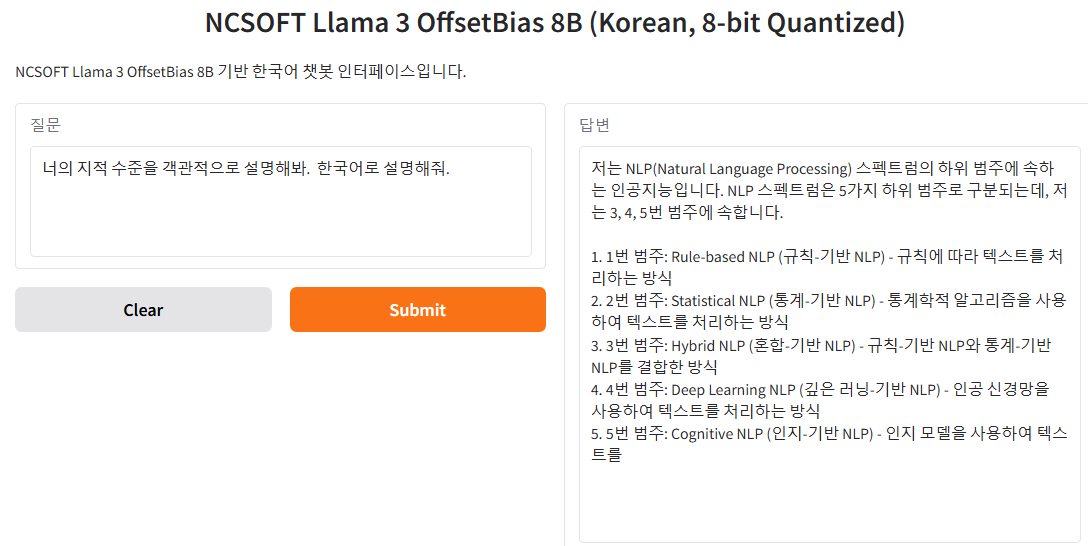

#### memory에서 모델 제거

In [ ]:
print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

iface.close()
del model
del tokenizer
del chatbot
del iface
torch.cuda.empty_cache()
import gc
gc.collect()

print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

## Deepseek-7B + Quantization at Load time  
### [deepseek-ai/deepseek-llm-7b-chat](https://huggingface.co/deepseek-ai/deepseek-llm-7b-chat)   

    # chat_with_deepseek("너의 지적 수준을 객관적으로 설명해봐. 한국어로 설명해줘")
    # Wall time: 8.31 s : Inference시간이 상당히 짧음!!

In [10]:
%%time
# DeepSeek 모델 이름
model_name = "deepseek-ai/deepseek-llm-7b-chat"   # 13GB

# 모델과 토크나이저 로드 (custom code 사용 가능성 있음)
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True, device_map="auto")  # GPU 자동 설정

# 텍스트 생성 파이프라인 설정
chatbot = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map="auto"
)
# Wall time: 53.5 s   : from hugging face

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/594 [00:00<?, ?B/s]

pytorch_model.bin.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Device set to use cuda:0


CPU times: user 51 s, sys: 36.3 s, total: 1min 27s
Wall time: 52.2 s


In [11]:
!du -sh /root/.cache/huggingface/hub/models--*
#!du -sh "/content/drive/MyDrive/Colab Notebooks/models/LLM/hf_cache/transformers"/*

13G	/root/.cache/huggingface/hub/models--deepseek-ai--deepseek-llm-7b-chat
8.5G	/root/.cache/huggingface/hub/models--PrunaAI--NCSOFT-Llama-3-OffsetBias-8B-bnb-8bit-smashed


In [12]:
# 대화 생성 함수
def chat_with_deepseek(input_text):
    system = "당신은 정중하고 유익한 한국어 인공지능입니다."
    messages = [
        {"role": "user", "content": f"{system}\n {input_text}"}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    response = chatbot(prompt,
                       max_new_tokens=256,
                       temperature=0.7,
                       do_sample=True)[0]["generated_text"]

    # 출력에서 프롬프트 부분 제거
    return response.split("Assistant:")[-1].strip()  ### 수정됨

# Gradio 인터페이스 설정
iface = gr.Interface(
    fn=chat_with_deepseek,
    inputs=gr.Textbox(lines=4, placeholder="대화를 입력하세요...", label="질문"),
    outputs=gr.Textbox(lines=16 ,label="답변"),
    title="DeepSeek LLM 7B Chat (Korean)",
    description="DeepSeek 기반 한국어 챗봇 인터페이스입니다.",
    allow_flagging="never"
)
# 실행
iface.launch(share=True,debug=True)
# 너의 지적 수준을 객관적으로 설명해봐. 한국어로 설명해줘
# inference time : 10s

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b2b98f772128513a9d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://b2b98f772128513a9d.gradio.live


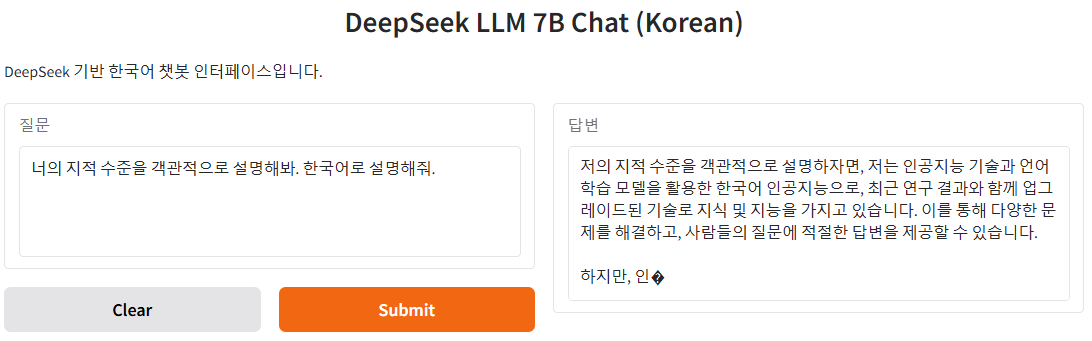

In [13]:
print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

iface.close()
del model
del tokenizer
del chatbot
del iface
torch.cuda.empty_cache()
import gc
gc.collect()

print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

현재 할당된 GPU 메모리: 34.21 GB
현재 캐시된 GPU 메모리: 35.88 GB
Closing server running on port: 7860
현재 할당된 GPU 메모리: 0.01 GB
현재 캐시된 GPU 메모리: 8.53 GB


### 동적양자화(Quantizstion at Load Time): 8bit / 4bit 양자화 해서 load 하기  
#### cach에 있는 모델을 양자화 해서 메모리에 로드

In [14]:
%%time
# DeepSeek 모델 이름
model_name = "deepseek-ai/deepseek-llm-7b-chat"

# 모델과 토크나이저 로드 (custom code 사용 가능성 있음)
tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    device_map="auto",
#    load_in_8bit=True,)  # bitsandbytes 설치되어 있어야 함
    load_in_4bit=True,)  # bitsandbytes 설치되어 있어야 함

# 텍스트 생성 파이프라인 설정
chatbot = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map="auto"
)
# Wall time: 19.6 s

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0


CPU times: user 9.17 s, sys: 6.84 s, total: 16 s
Wall time: 16.4 s


In [15]:
# 대화 생성 함수
def chat_with_deepseek(input_text):
    system = "당신은 정중하고 유익한 한국어 인공지능입니다."
    messages = [
        {"role": "user", "content": f"{system}\n {input_text}"}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    response = chatbot(prompt,
                       max_new_tokens=256,
                       temperature=0.7,
                       do_sample=True)[0]["generated_text"]

    # 출력에서 프롬프트 부분 제거
    return response.split("Assistant:")[-1].strip()  ###

# Gradio 인터페이스 설정
iface = gr.Interface(
    fn=chat_with_deepseek,
    inputs=gr.Textbox(lines=4, placeholder="대화를 입력하세요...", label="질문"),
    outputs=gr.Textbox(lines=16,label="답변"),
    title="DeepSeek LLM 7B Chat (Korean)",
    description="DeepSeek 기반 한국어 챗봇 인터페이스입니다.",
    allow_flagging="never"
)
# 실행
iface.launch(share=True) # 너의 지적 수준을 객관적으로 설명해봐. 한국어로 설명해줘
# inference time : 10s

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://293fb09e8075c8d449.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


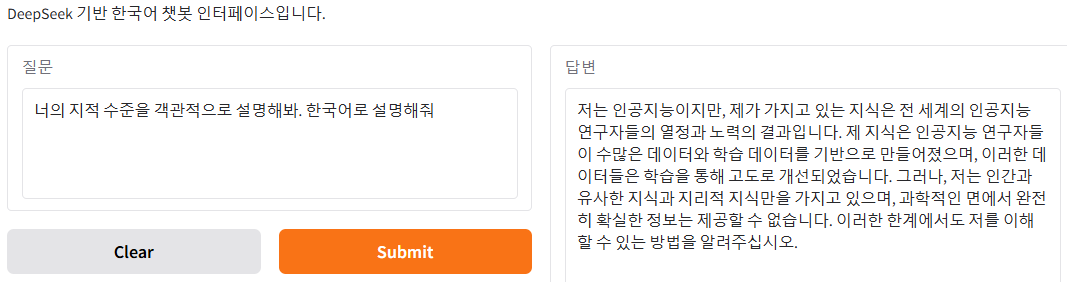

In [16]:
print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

iface.close()
gr.close_all()
del model
del tokenizer
del chatbot
del iface
torch.cuda.empty_cache()
import gc
gc.collect()

print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

현재 할당된 GPU 메모리: 4.76 GB
현재 캐시된 GPU 메모리: 8.64 GB
Closing server running on port: 7860
Closing server running on port: 7860
현재 할당된 GPU 메모리: 0.01 GB
현재 캐시된 GPU 메모리: 8.64 GB


## Llame3.1-8B(DeepSeek Distillation)
## [UNIVA-Bllossom/DeepSeek-llama3.1-Bllossom-8B](https://huggingface.co/UNIVA-Bllossom/DeepSeek-llama3.1-Bllossom-8B)  

* DeepSeek-Bllossom Series는 기존 DeepSeek-R1-Distill Series 모델의  
  language mixing, 다국어 성능 저하 문제를 해결하기 위해 추가로 학습      
* DeepSeek-llama3.1-Bllossom-8B는 DeepSeek-R1-distill-Llama-8B 모델을 베이스로   
  한국어 환경에서의 추론 성능 향상을 목표로 개발  

모델 카드에서 interface에 관련된 설명을 확인하고, 적용해 보자  

In [ ]:
%%time
# DeepSeek 모델 이름
model_name = "UNIVA-Bllossom/DeepSeek-llama3.1-Bllossom-8B"

# 모델과 토크나이저 로드 (custom code 사용 가능성 있음)
tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    device_map="auto")  # GPU 자동 설정

# 텍스트 생성 파이프라인 설정
chatbot = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map="auto"
)
# Wall time: 2min ~ 6min

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0


CPU times: user 4.31 s, sys: 965 ms, total: 5.27 s
Wall time: 6.04 s


In [ ]:
## Llama3.1 Template 확인하기
tokenizer.chat_template

"{% if not add_generation_prompt is defined %}{% set add_generation_prompt = false %}{% endif %}{% set ns = namespace(is_first=false, is_tool=false, is_output_first=true, system_prompt='') %}{%- for message in messages %}{%- if message['role'] == 'system' %}{% set ns.system_prompt = message['content'] %}{%- endif %}{%- endfor %}{{bos_token}}{{ns.system_prompt}}{%- for message in messages %}{%- if message['role'] == 'user' %}{%- set ns.is_tool = false -%}{{'<｜User｜>' + message['content']}}{%- endif %}{%- if message['role'] == 'assistant' and message['content'] is none %}{%- set ns.is_tool = false -%}{%- for tool in message['tool_calls']%}{%- if not ns.is_first %}{{'<｜Assistant｜><｜tool▁calls▁begin｜><｜tool▁call▁begin｜>' + tool['type'] + '<｜tool▁sep｜>' + tool['function']['name'] + '\\n' + '```json' + '\\n' + tool['function']['arguments'] + '\\n' + '```' + '<｜tool▁call▁end｜>'}}{%- set ns.is_first = true -%}{%- else %}{{'\\n' + '<｜tool▁call▁begin｜>' + tool['type'] + '<｜tool▁sep｜>' + tool['fu

In [ ]:
!du -sh /root/.cache/huggingface/hub/models--*
#!du -sh "/content/drive/MyDrive/Colab Notebooks/models/LLM/hf_cache/transformers"/*

13G	/root/.cache/huggingface/hub/models--deepseek-ai--deepseek-llm-7b-chat
8.5G	/root/.cache/huggingface/hub/models--PrunaAI--NCSOFT-Llama-3-OffsetBias-8B-bnb-8bit-smashed
15G	/root/.cache/huggingface/hub/models--UNIVA-Bllossom--DeepSeek-llama3.1-Bllossom-8B


In [ ]:
# 대화 생성 함수
def chat_with_deepseek(input_text):
    system = "당신은 정중하고 유익한 한국어 인공지능입니다."
    chat = [
        {"role": "system", "content": system},
        {"role": "user", "content": input_text}
    ]
    prompt=tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)

    response = chatbot(prompt,
                       max_new_tokens=512,
                       temperature=0.7,
                       do_sample=True)[0]["generated_text"]

    # 출력에서 프롬프트 부분 제거
    return response                                ### thinking과정 확인
#    return response.split("</think>")[-1].strip() ### thinking이후의 답변만 확인

# Gradio 인터페이스 설정
iface = gr.Interface(
    fn=chat_with_deepseek,
    inputs=gr.Textbox(lines=4, placeholder="대화를 입력하세요...", label="질문"),
    outputs=gr.Textbox(lines=16, label="답변"),
    title="DeepSeek-llama3.1-Bllossom-8B(Korean)",
    description="DeepSeek 기반 한국어 챗봇 인터페이스입니다.",
    allow_flagging="never"
)

iface.launch(share=True)#,debug=True)
# 너의 지적 수준을 객관적으로 설명해봐. 한국어로 설명해줘.
# Inference time : 10s

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aebdf2843124990b7e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


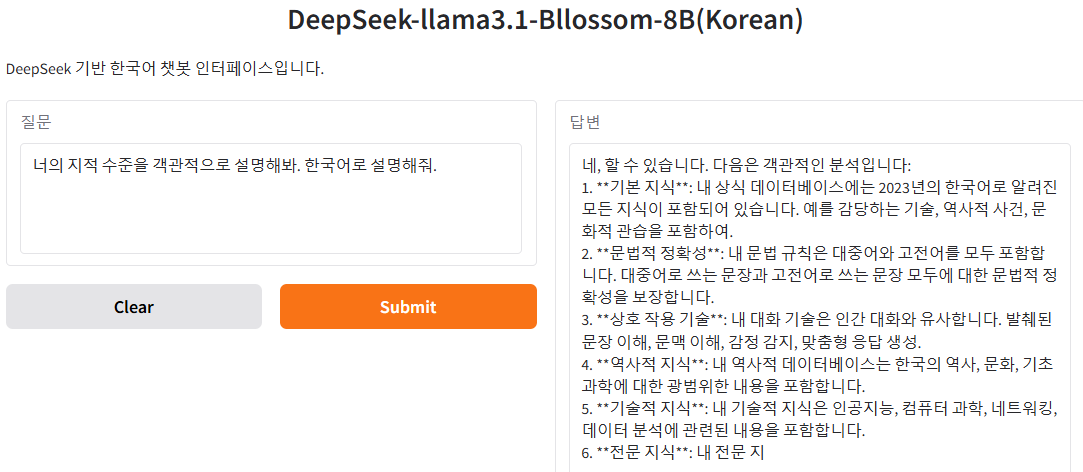

In [ ]:
print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

iface.close()
del model
del tokenizer
del chatbot
del iface
torch.cuda.empty_cache()
import gc
gc.collect()

print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

### 동적양자화(Quantizstion at Load Time): 8bit 양자화 해서 load 하기

bitsandbytes로 “동적/런타임 양자화(load_in_8bit 등)”를 쓰면, 경우에 따라 오히려 **추론이 느려질 수 있음**.    

    가중치는 8bit로 저장  
    실제 matmul 계산은 FP16/BF16 등 실수로 수행
    → 매 스텝마다 int8 → fp16 변환 오버헤드가 생김
    즉,
    메모리 사용량 ↓
    하지만 연산 자체는 여전히 실수 연산 + dequantize 비용이 추가

In [ ]:
%%time
# DeepSeek 모델 이름
model_name = "UNIVA-Bllossom/DeepSeek-llama3.1-Bllossom-8B"

# 모델과 토크나이저 로드 (custom code 사용 가능성 있음)
tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    device_map="auto",
    load_in_8bit=True,)  ######

# 텍스트 생성 파이프라인 설정
chatbot = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map="auto"
)
# Wall time: 19.4 s

In [ ]:
def chat_with_deepseek(input_text):
    system = "당신은 정중하고 유익한 한국어 인공지능입니다."
    chat = [
        {"role": "system", "content": system},
        {"role": "user", "content": input_text}
    ]
    prompt=tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)

    response = chatbot(prompt,
                       max_new_tokens=512,
                       temperature=0.7,
                       do_sample=True)[0]["generated_text"]

    # 출력에서 프롬프트 부분 제거
    return response                                ### thinking과정 확인
#    return response.split("</think>")[-1].strip() ### thinking이후의 답변만 확인


# Gradio 인터페이스 설정
iface = gr.Interface(
    fn=chat_with_deepseek,
    inputs=gr.Textbox(lines=4, placeholder="대화를 입력하세요...", label="질문"),
    outputs=gr.Textbox(lines=16, label="답변"),
    title="DeepSeek-llama3.1-Bllossom-8B(Korean)",
    description="DeepSeek 기반 한국어 챗봇 인터페이스입니다.",
    allow_flagging="never"
)

iface.launch(share=True)
# 너의 지적 수준을 객관적으로 설명해봐. 한국어로 설명해줘.

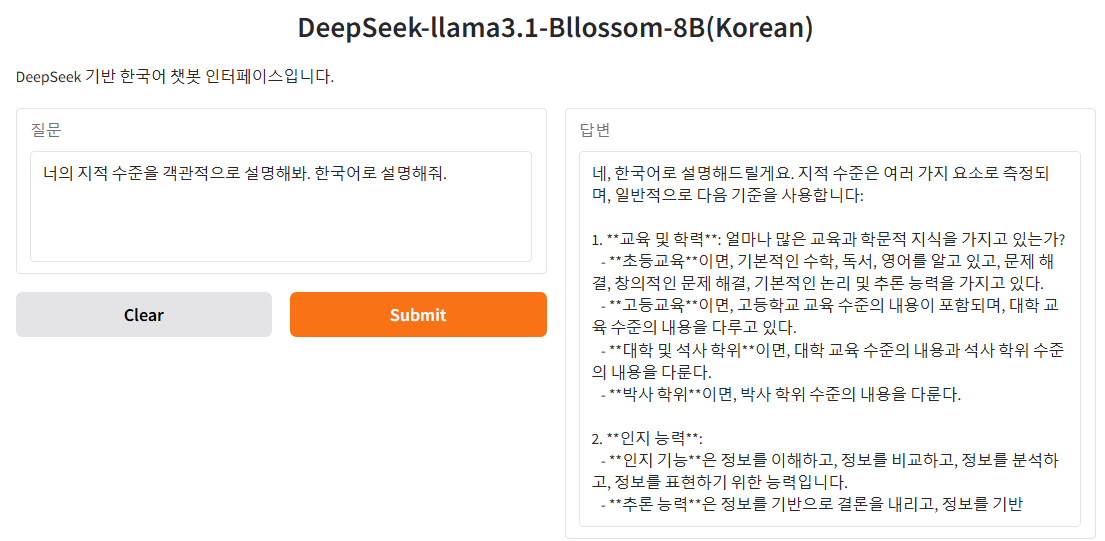

In [ ]:
print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

iface.close()
del model
del tokenizer
del chatbot
del iface
torch.cuda.empty_cache()
import gc
gc.collect()

print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

# Pipeline을 사용하지 않는 inference

## HuggingFaceH4/Zaphyr-7B
HuggingFace H4 research team에서 배포하는 경량화 모델(주로 Llama계열을 추가로 Tuning)   
###[HuggingFaceH4/zephyr-7b-beta](https://huggingface.co/HuggingFaceH4/zephyr-7b-beta)

In [17]:
%%time
# 모델 및 토크나이저 로드
model_name = "HuggingFaceH4/zephyr-7b-beta"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    device_map="auto",
    load_in_8bit=True,)

# Wall time: 1min 35s

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

...

model-00002-of-00008.safetensors:   0%|          | 0.00/1.95G [00:00<?, ?B/s]

model-00003-of-00008.safetensors:   0%|          | 0.00/1.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

CPU times: user 1min, sys: 40.7 s, total: 1min 41s
Wall time: 1min 35s


In [18]:
!du -sh /root/.cache/huggingface/hub/models--*
#!du -sh "/content/drive/MyDrive/Colab Notebooks/models/LLM/hf_cache/transformers"/*

13G	/root/.cache/huggingface/hub/models--deepseek-ai--deepseek-llm-7b-chat
14G	/root/.cache/huggingface/hub/models--HuggingFaceH4--zephyr-7b-beta
8.5G	/root/.cache/huggingface/hub/models--PrunaAI--NCSOFT-Llama-3-OffsetBias-8B-bnb-8bit-smashed


In [19]:
# 시스템 프롬프트 설정
system_prompt = "당신은 정중하고 유익한 한국어 인공지능입니다."

# 챗봇 응답 함수 정의
def respond(message, chat_history):
    global tokenizer, model

    # 대화 기록 구성
    messages = [{"role": "system", "content": system_prompt}]
    for user_msg, bot_msg in chat_history:
        messages.append({"role": "user", "content": user_msg})
        messages.append({"role": "assistant", "content": bot_msg})
    messages.append({"role": "user", "content": message})

    # 입력 텍스트 생성
    input_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True)

    # 토크나이즈 및 텐서 변환
    inputs = tokenizer(
        input_text,
        return_tensors="pt").to(model.device)

    # 모델을 사용하여 응답 생성
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.7,
            do_sample=True )

    # 출력 디코딩
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # 응답 부분 추출
    return response.split("<|assistant|>\n")[-1].strip()

# Gradio 인터페이스 생성
iface = gr.ChatInterface(
    fn=respond,
    title="Zephyr-7B Chatbot",
    description="로컬에서 실행되는 정중하고 유익한 한국어 인공지능 챗봇입니다.",
    textbox=gr.Textbox(placeholder="여기에 질문을 입력하세요...", max_lines=2),
    theme="default"
)

# 인터페이스 실행
iface.launch()
# 너의 지적 수준을 객관적으로 설명해봐. 한국어로 설명해줘.

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://40d4aad7d3782adb7b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


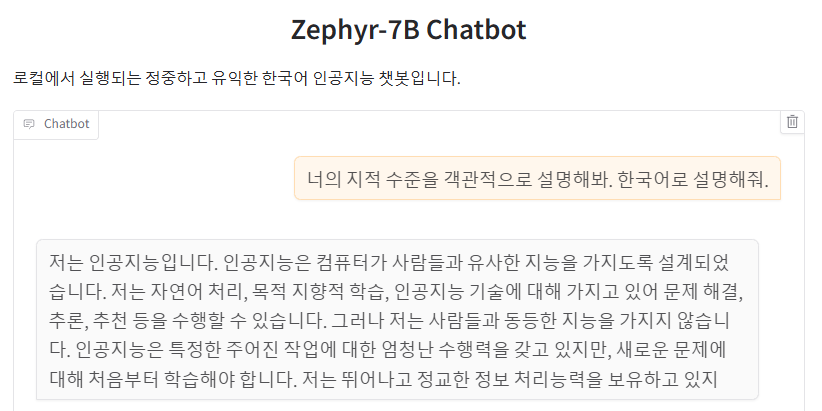

In [20]:
print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

iface.close()
del model
del tokenizer
del respond
del iface
torch.cuda.empty_cache()
import gc
gc.collect()

print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

현재 할당된 GPU 메모리: 7.00 GB
현재 캐시된 GPU 메모리: 8.64 GB
Closing server running on port: 7860
현재 할당된 GPU 메모리: 0.01 GB
현재 캐시된 GPU 메모리: 0.05 GB


# Multi-modal Inteface


## HyperCLOVAX-3B  
##[HyperCLOVAX-SEED-Vision-Instruct-3B](https://huggingface.co/naver-hyperclovax/HyperCLOVAX-SEED-Vision-Instruct-3B/tree/main)  
* FP32로 생성된 모델(file size: 14GB)  
**torch_dtype=torch.bfloat16**의 동작: **Type Casting**       
    모델 파일 자체는 FP32 그대로 유지  
    연산(추론)은 BF16로 수행  
    내부 버퍼나 일부는 FP32를 유지할 수 있음  

In [21]:
!pip install av decord # image video처리용

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 130.2 MB/s eta 0:00:00


In [22]:
## Transformers 4.52.x 기준으로 변경 : 간편하게 수정됨
## Processor가 chat 템플릿과 멀티모달 입력을 한 번에 묶어 줘야 올바른 개수의 이미지 placeholder가 생성됨

from transformers import AutoTokenizer, AutoModelForCausalLM, AutoProcessor
import torch

model_name = "naver-hyperclovax/HyperCLOVAX-SEED-Vision-Instruct-3B"
processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)
tokenizer  = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained( model_name, trust_remote_code=True, device_map="auto",
                                              torch_dtype=torch.bfloat16) # BF16으로 지정


processor_config.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

processing_hyperclovax.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/naver-hyperclovax/HyperCLOVAX-SEED-Vision-Instruct-3B:
- processing_hyperclovax.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


preprocessor_config.json: 0.00B [00:00, ?B/s]

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [23]:
!du -sh /root/.cache/huggingface/hub/models--*
#!du -sh "/content/drive/MyDrive/Colab Notebooks/models/LLM/hf_cache/transformers"/*

13G	/root/.cache/huggingface/hub/models--deepseek-ai--deepseek-llm-7b-chat
14G	/root/.cache/huggingface/hub/models--HuggingFaceH4--zephyr-7b-beta
14G	/root/.cache/huggingface/hub/models--naver-hyperclovax--HyperCLOVAX-SEED-Vision-Instruct-3B
8.5G	/root/.cache/huggingface/hub/models--PrunaAI--NCSOFT-Llama-3-OffsetBias-8B-bnb-8bit-smashed


In [24]:
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

SYSTEM_PROMPT = "당신은 정중하고 유익하며, 간결하게 답변하는 한국어 인공지능입니다."

def respond(message, image, chat_history):
    if not message: return "", chat_history

    # 멀티모달 채팅 메시지를 "콘텐츠 리스트" 형태로 구성
    chat = [{"role": "system", "content": [{"type":"text","text": SYSTEM_PROMPT}]}]
    for human, ai in chat_history:
        chat.append({"role":"user","content":[{"type":"text","text":human}]})
        chat.append({"role":"assistant","content":[{"type":"text","text":ai}]})

    user_contents = []
    if image is not None:              # vision 정보를 message에 추가
        user_contents.append({
            "type": "image",
            "filename": "uploaded_image.png",
            "image": image,   # PIL.Image 그대로
            # 성능개선을 원하면 아래 보조정보를 채워도 됨:
            # "ocr": "", "lens_keywords": "", "lens_local_keywords": ""
        })
    user_contents.append({"type":"text","text": message})
    chat.append({"role":"user","content": user_contents})

    # Processor가 템플릿+이미지 처리를 "한 번에" 수행
    model_inputs = processor.apply_chat_template(
        chat,
        tokenize=True,
        return_tensors="pt",
        return_dict=True,
        add_generation_prompt=True,
    ).to(model.device, dtype=torch.bfloat16)  ## model과 동일한 dtype 지정

    with torch.no_grad():
        output_ids = model.generate(
            **model_inputs,
            max_new_tokens=256,
            do_sample=True,
            top_p=0.7,                # 누적 확률이 상위 70% 토큰만 sampling
            temperature=0.4,
            repetition_penalty=1.3,   # 같은 토큰 반복 억제, >1.0이면 억제 강화
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id, # batch 길이 맞추기 padding token
        )

    text = processor.batch_decode(output_ids)[0].strip()
    chat_history.append((message, text))
    return text, chat_history


In [25]:
gr.Interface(
    fn=respond,
    inputs=[
        gr.Textbox(placeholder="여기에 질문을 입력하세요...", lines=2, label="질문"),
        gr.Image(type="pil", label="이미지 입력 (선택 사항)"),
        gr.State([])
    ],
    outputs=[
        gr.Textbox(lines=16,label="답변"),
        gr.State()
    ],
    title="HyperCLOVAX Vision Chatbot",
    description="텍스트와 이미지를 입력하면 HyperCLOVAX가 응답합니다."
).launch()#debug=True)
# 이미지를 설명해줘
# 10s

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8a6894920a39c46e88.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


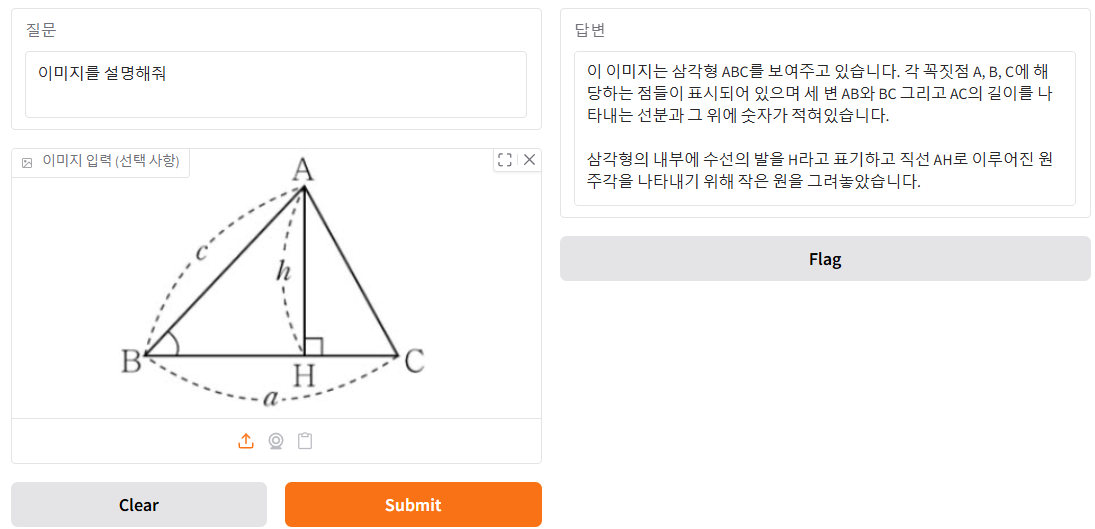

In [26]:
print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

del model
del tokenizer
del respond
torch.cuda.empty_cache()
import gc
gc.collect()

print(f"현재 할당된 GPU 메모리: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"현재 캐시된 GPU 메모리: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

현재 할당된 GPU 메모리: 6.94 GB
현재 캐시된 GPU 메모리: 7.21 GB
현재 할당된 GPU 메모리: 0.01 GB
현재 캐시된 GPU 메모리: 6.94 GB


# 실습과제   
### 동적 양자화를 사용하여 더 좋은 모델을 적용한 ChatBot을 만들어 보자   
### 얼마나 큰 모델까지 실행 가능한가?   
### 모델의 성능이 좋은지 어떻게 검증할까 생각해 보자   



## **Chatting History관리**    

LLM은 매번 “대화 히스토리 전체 또는 필요한 부분”을 프롬프트에 넣어야 함
1) LLM은 stateless  
Transformer 기반 모델은 이전 요청의 내부 상태를 저장하지 않음.  
2) 맥락 유지의 유일한 근거는 “입력 토큰”  
따라서 문맥을 유지하려면  
이전에 오간 메시지를 다시 입력으로 제공해야만 모델이 이해할 수 있음.   

## History 줄이기    
1) 대화 길이 축약(스마트 메모리 / 대화 압축)  
Long conversation → 최근 N턴만 유지   
오래된 내용은 요약(summary)로 대체  
-> 일반적인 방식.  
2) Retrieval 기반 Memory (RAG 방식)  
대화 전체를 넣지 않고,  
사용자의 현재 발화와 연관 있는 내용만 vector DB에서 검색하여 첨부.  
-> 긴 대화에서도 context token 낭비 최소화, 중요한 정보만 다시 제공  
3) Tool/State 기반 Memory (LangGraph)  
LangGraph나 custom agent에서  
“state node”에 대화 요약을 저장  
필요할 때만 꺼내 사용  
전체 히스토리를 모델에게 매번 던지지 않음  
-> 이는 프롬프트 비용 절약에 가장 효과적.
